<a href="https://colab.research.google.com/github/prithviratkalkar2304-coder/IMBD_Top_1000_Movies-EDA-Project-/blob/main/IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing all the libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

##Loading the DataSet

In [ ]:
df = pd.read_csv("/content/IMDb top 1000 movies.csv")
df.head(3)

,Unnamed: 0,Movie Name,Certificate,Duration,Genre,IMDb Rating,Metascore,Director,Stars,Votes,Grossed in $,Plot
0,0,The Shawshank Redemption,R,142 min,Drama,9.3,82.0,Frank Darabont,"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...",2807416,2807416,"Over the course of several years, two convicts..."
1,1,The Godfather,R,175 min,"Crime, Drama",9.2,100.0,Francis Ford Coppola,"['Marlon Brando', 'Al Pacino', 'James Caan', '...",1956381,1956381,"Don Vito Corleone, head of a mafia family, dec..."
2,2,The Dark Knight,PG-13,152 min,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...",2789160,2789160,When the menace known as the Joker wreaks havo...


##General Information Dataset

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1000 non-null   int64  
 1   Movie Name    1000 non-null   object 
 2   Certificate   985 non-null    object 
 3   Duration      1000 non-null   object 
 4   Genre         1000 non-null   object 
 5   IMDb Rating   1000 non-null   float64
 6   Metascore     845 non-null    float64
 7   Director      1000 non-null   object 
 8   Stars         1000 non-null   object 
 9   Votes         1000 non-null   int64  
 10  Grossed in $  1000 non-null   int64  
 11  Plot          1000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 93.9+ KB


In [ ]:
print(f'Count of IMDB to 1000 Movies rows : {df.shape[0]}')
print(f'Count of IMDB to 1000 Movies columns : {df.shape[1]}')

Count of IMDB to 1000 Movies rows : 1000
Count of IMDB to 1000 Movies columns : 12


#Missing Values and Duplicated Checking
##Missing Values Checking

In [ ]:

count = df.isna().sum().sort_values(ascending=False)
percent = round(df.isna().mean()*100,2).sort_values(ascending=False)
missing_values = pd.concat([count, percent], axis=1, keys=['count','percent'])
print(missing_values,'\n')
print('Total of Missing Values ', df.shape[0] - df.dropna().shape[0])
print('Total Percentage of Missing Values ', (df.shape[0] - df.dropna().shape[0])/df.shape[0]*100,'%')

              count  percent
Metascore       155     15.5
Certificate      15      1.5
Movie Name        0      0.0
Unnamed: 0        0      0.0
Duration          0      0.0
Genre             0      0.0
IMDb Rating       0      0.0
Director          0      0.0
Stars             0      0.0
Votes             0      0.0
Grossed in $      0      0.0
Plot              0      0.0 

Total of Missing Values  158
Total Percentage of Missing Values  15.8 %


##Duplicate Checking

In [ ]:

print('Duplicated Values :', df.duplicated().sum())

Duplicated Values : 0


In [ ]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis = 1, inplace=True)
df.head(3)

,Movie Name,Certificate,Duration,Genre,IMDb Rating,Metascore,Director,Stars,Votes,Grossed in $,Plot
0,The Shawshank Redemption,R,142 min,Drama,9.3,82.0,Frank Darabont,"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...",2807416,2807416,"Over the course of several years, two convicts..."
1,The Godfather,R,175 min,"Crime, Drama",9.2,100.0,Francis Ford Coppola,"['Marlon Brando', 'Al Pacino', 'James Caan', '...",1956381,1956381,"Don Vito Corleone, head of a mafia family, dec..."
2,The Dark Knight,PG-13,152 min,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...",2789160,2789160,When the menace known as the Joker wreaks havo...


##Impute Missing Values in Metascore Columns using Mean

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Movie Name    1000 non-null   object 
 1   Certificate   985 non-null    object 
 2   Duration      1000 non-null   object 
 3   Genre         1000 non-null   object 
 4   IMDb Rating   1000 non-null   float64
 5   Metascore     845 non-null    float64
 6   Director      1000 non-null   object 
 7   Stars         1000 non-null   object 
 8   Votes         1000 non-null   int64  
 9   Grossed in $  1000 non-null   int64  
 10  Plot          1000 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 86.1+ KB


In [ ]:
df['Metascore'].fillna(df['Metascore'].mean(), inplace=True)

/tmp/ipykernel_695/1805874602.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Metascore'].fillna(df['Metascore'].mean(), inplace=True)


In [ ]:

df['Metascore'].isna().sum()


np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Movie Name    1000 non-null   object 
 1   Certificate   985 non-null    object 
 2   Duration      1000 non-null   object 
 3   Genre         1000 non-null   object 
 4   IMDb Rating   1000 non-null   float64
 5   Metascore     1000 non-null   float64
 6   Director      1000 non-null   object 
 7   Stars         1000 non-null   object 
 8   Votes         1000 non-null   int64  
 9   Grossed in $  1000 non-null   int64  
 10  Plot          1000 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 86.1+ KB


##Drop Missing Values in Certicate Columns

In [ ]:

df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 985 entries, 0 to 998
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Movie Name    985 non-null    object 
 1   Certificate   985 non-null    object 
 2   Duration      985 non-null    object 
 3   Genre         985 non-null    object 
 4   IMDb Rating   985 non-null    float64
 5   Metascore     985 non-null    float64
 6   Director      985 non-null    object 
 7   Stars         985 non-null    object 
 8   Votes         985 non-null    int64  
 9   Grossed in $  985 non-null    int64  
 10  Plot          985 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 92.3+ KB


##Convert Duration Column Type to Integer

In [ ]:

if df['Duration'].dtype == 'object':
    df['Duration'] = df['Duration'].apply(lambda x:x.replace(' min', ''))
    df['Duration'] = df['Duration'].astype('int64')

In [ ]:
df.head(3)


,Movie Name,Certificate,Duration,Genre,IMDb Rating,Metascore,Director,Stars,Votes,Grossed in $,Plot
0,The Shawshank Redemption,R,142,Drama,9.3,82.0,Frank Darabont,"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...",2807416,2807416,"Over the course of several years, two convicts..."
1,The Godfather,R,175,"Crime, Drama",9.2,100.0,Francis Ford Coppola,"['Marlon Brando', 'Al Pacino', 'James Caan', '...",1956381,1956381,"Don Vito Corleone, head of a mafia family, dec..."
2,The Dark Knight,PG-13,152,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...",2789160,2789160,When the menace known as the Joker wreaks havo...


##Separate Multiple Genre into List

In [ ]:

df['Genre'] = df['Genre'].apply(lambda x: x.split(', ') if isinstance(x, str) else x)

In [ ]:
df.head(3)

,Movie Name,Certificate,Duration,Genre,IMDb Rating,Metascore,Director,Stars,Votes,Grossed in $,Plot
0,The Shawshank Redemption,R,142,[Drama],9.3,82.0,Frank Darabont,"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...",2807416,2807416,"Over the course of several years, two convicts..."
1,The Godfather,R,175,"[Crime, Drama]",9.2,100.0,Francis Ford Coppola,"['Marlon Brando', 'Al Pacino', 'James Caan', '...",1956381,1956381,"Don Vito Corleone, head of a mafia family, dec..."
2,The Dark Knight,PG-13,152,"[Action, Crime, Drama]",9.0,84.0,Christopher Nolan,"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...",2789160,2789160,When the menace known as the Joker wreaks havo...


##Remove Special Character in Stars Column

In [ ]:

def remove_character(stars):
    char_remove = ["'","/",'"',"[","]"]

    for char in char_remove:
        stars = stars.replace(char, '')
    return stars
df['Stars'] = df['Stars'].apply(lambda x: remove_character(x))
df.head(3)

,Movie Name,Certificate,Duration,Genre,IMDb Rating,Metascore,Director,Stars,Votes,Grossed in $,Plot
0,The Shawshank Redemption,R,142,[Drama],9.3,82.0,Frank Darabont,"Tim Robbins, Morgan Freeman, Bob Gunton, Willi...",2807416,2807416,"Over the course of several years, two convicts..."
1,The Godfather,R,175,"[Crime, Drama]",9.2,100.0,Francis Ford Coppola,"Marlon Brando, Al Pacino, James Caan, Diane Ke...",1956381,1956381,"Don Vito Corleone, head of a mafia family, dec..."
2,The Dark Knight,PG-13,152,"[Action, Crime, Drama]",9.0,84.0,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart, M...",2789160,2789160,When the menace known as the Joker wreaks havo...


##Separate Stars Cast into List

In [ ]:

df['Stars'] = df['Stars'].apply(lambda x: x.split(', ') if isinstance(x, str) else x)

# Statistical Descriptive
## Separate Numeric and Categorical Columns

In [ ]:

categorical = df.select_dtypes(include='object').columns
numerical = df.select_dtypes(exclude='object').columns

##Value Count on each Categorical Data

In [ ]:

for col in categorical:
    print(f'Total values in {col}')
    print('--------')
    print(df[col].value_counts(),'\n')

Total values in Movie Name
--------
Movie Name
Beauty and the Beast               2
Scarface                           2
The Girl with the Dragon Tattoo    2
All Quiet on the Western Front     2
Drishyam                           2
                                  ..
Anand                              1
Sarfarosh                          1
Past Lives                         1
Dune                               1
Jean de Florette                   1
Name: count, Length: 980, dtype: int64 

Total values in Certificate
--------
Certificate
R            356
Not Rated    183
PG-13        166
PG           141
Passed        47
G             38
Approved      30
TV-MA          7
TV-PG          4
TV-14          3
GP             3
16+            2
NC-17          2
18+            1
M/PG           1
Unrated        1
Name: count, dtype: int64 

Total values in Genre
--------
Genre
[Drama]                         91
[Drama, Romance]                40
[Comedy, Drama]                 32
[Comedy, Drama

##Statistical Descriptive Categorical Columns

In [ ]:

df[categorical].describe().T

,count,unique,top,freq
Movie Name,985,980,Beauty and the Beast,2
Certificate,985,16,R,356
Genre,985,194,[Drama],91
Director,985,550,Alfred Hitchcock,12
Stars,985,983,"[Prabhas, Rana Daggubati, Anushka Shetty, Tama...",2
Plot,985,985,"Pianist David Helfgott, driven by his father a...",1


##Statistical Descriptive Numerical Columns

In [ ]:

df[numerical].describe().T

,count,mean,std,min,25%,50%,75%,max
Duration,985.0,124.012183,28.686203,45.0,103.0,120.000000,138.0,321.0
IMDb Rating,985.0,7.968020,0.272862,7.6,7.8,7.900000,8.1,9.3
Metascore,985.0,79.041781,11.076324,28.0,73.0,79.071006,86.0,100.0
Votes,985.0,326224.755330,393273.407643,25616.0,63825.0,163662.000000,451582.0,2807416.0
Grossed in $,985.0,326224.755330,393273.407643,25616.0,63825.0,163662.000000,451582.0,2807416.0


##Total Movies in Top 1000 IMDB Movies By Certificate

/tmp/ipykernel_695/1441349881.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = certificate.values, y = certificate.index,
/tmp/ipykernel_695/1441349881.py:3: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = certificate.values, y = certificate.index,


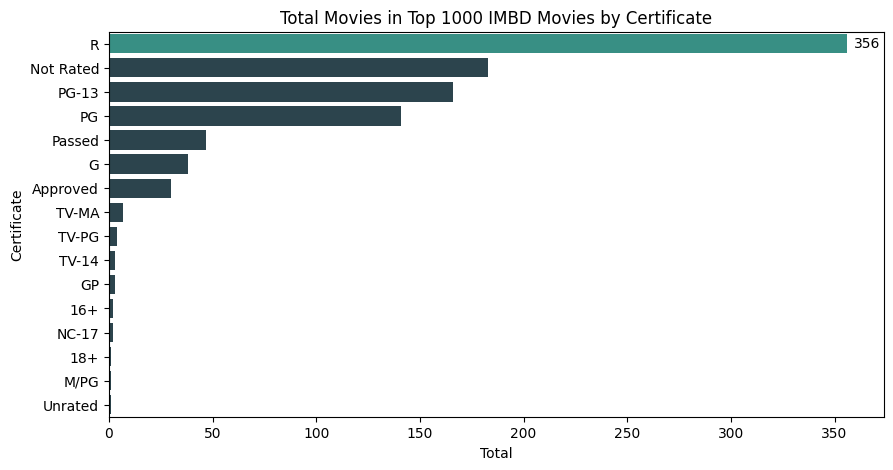

In [ ]:

plt.figure(figsize=(10,5))
certificate = df['Certificate'].value_counts()
ax = sns.barplot(x = certificate.values, y = certificate.index,
                 palette=np.where(certificate.values == np.max(certificate.values), '#2a9d8f','#264653'))
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlabel('Total')
plt.title('Total Movies in Top 1000 IMBD Movies by Certificate')
plt.show()

## Genre in Top 1000 IMDB Movies
## Most Genres in Top 1000 IMDB Movies

In [ ]:

all_genres = [genre for sublist in df['Genre'] for genre in sublist]
genre_counts = pd.Series(all_genres).value_counts()
genre_counts.index

Index(['Drama', 'Comedy', 'Action', 'Crime', 'Adventure', 'Thriller',
       'Romance', 'Biography', 'Mystery', 'Animation', 'Sci-Fi', 'Fantasy',
       'Family', 'War', 'History', 'Music', 'Horror', 'Film-Noir', 'Western',
       'Musical', 'Sport'],
      dtype='object')

/tmp/ipykernel_695/2236278469.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = genre_counts.values, y = genre_counts.index,
/tmp/ipykernel_695/2236278469.py:2: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = genre_counts.values, y = genre_counts.index,


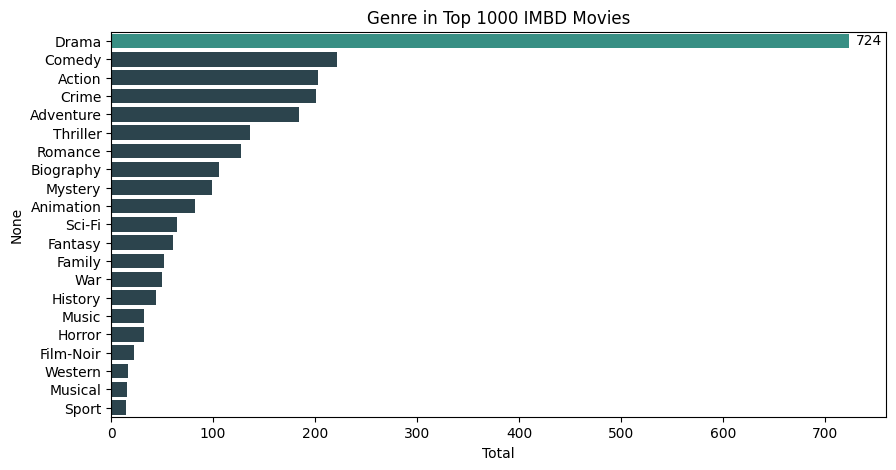

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x = genre_counts.values, y = genre_counts.index,
                 palette=np.where(genre_counts.values == np.max(genre_counts.values), '#2a9d8f','#264653'))
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlabel('Total')
plt.title('Genre in Top 1000 IMBD Movies')
plt.show()

## Movies with Multiple Genre

In [ ]:

multiple_genre = ['Genre'+' '+ str(len(genre)) for genre in df['Genre']]
multiple_genre_counts = pd.Series(multiple_genre).value_counts()
multiple_genre_counts

,count
Genre 3,627
Genre 2,251
Genre 1,107


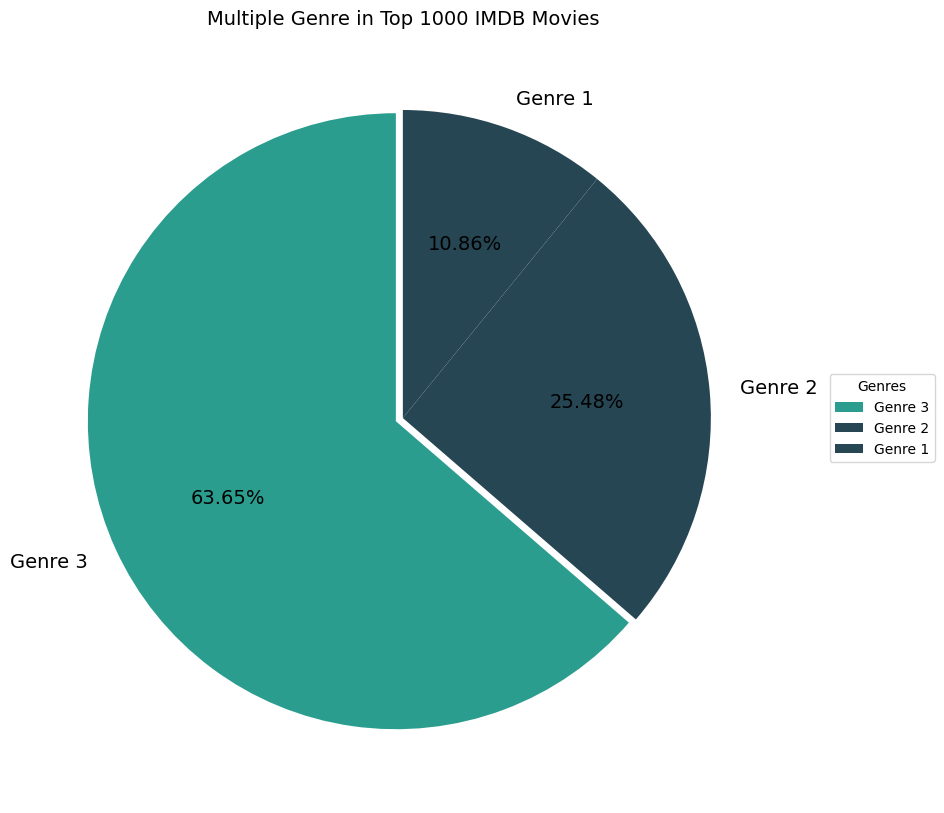

In [ ]:
plt.figure(figsize=(10,10))
plt.pie(multiple_genre_counts, autopct='%.2f%%', labels= multiple_genre_counts.index,
       colors = np.where(multiple_genre_counts.values == np.max(multiple_genre_counts.values), '#2a9d8f','#264653'),
       explode=(0.025,0,0), startangle=90, textprops={'fontsize':14})
plt.legend(title = 'Genres', loc = 'right', bbox_to_anchor=(1.2, .5))
plt.title('Multiple Genre in Top 1000 IMDB Movies', fontdict={'fontsize':14})
plt.show()

## Top 10 Star Casts in Top 1000 IMDB Movies


In [ ]:
# Since the Stars column has many unique values, the scope will be narrowed down to the top 10 Stars.

all_stars = [stars for sublist in df['Stars'] for stars in sublist]
all_stars_counts = pd.Series(all_stars).value_counts()

/tmp/ipykernel_695/2177521653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = stars.values, y = stars.index,
/tmp/ipykernel_695/2177521653.py:3: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = stars.values, y = stars.index,


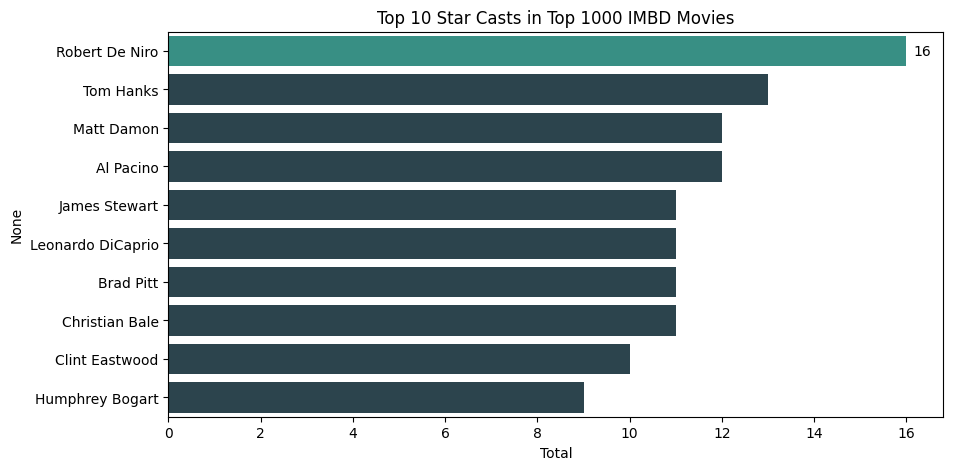

In [ ]:
plt.figure(figsize=(10,5))
stars = all_stars_counts.head(10)
ax = sns.barplot(x = stars.values, y = stars.index,
                 palette=np.where(stars.values == np.max(stars.values), '#2a9d8f','#264653'))
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlabel('Total')
plt.title('Top 10 Star Casts in Top 1000 IMBD Movies')
plt.show()

## Top 10 Directors in Top 1000 IMDB Movies


/tmp/ipykernel_695/744990006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = director.values, y = director.index,
/tmp/ipykernel_695/744990006.py:4: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = director.values, y = director.index,


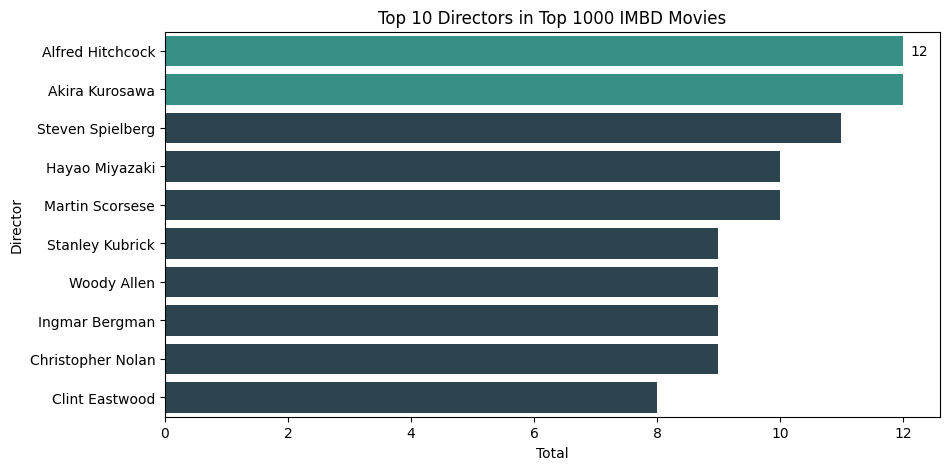

In [ ]:
# Since the director column has many unique values, the scope will be narrowed down to the top 10 directors.
plt.figure(figsize=(10,5))
director = df['Director'].value_counts().head(10)
ax = sns.barplot(x = director.values, y = director.index,
                 palette=np.where(director.values == np.max(director.values), '#2a9d8f','#264653'))
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlabel('Total')
plt.title('Top 10 Directors in Top 1000 IMBD Movies')
plt.show()

# Univariate Analysis Numerical Columns
## Distribution Plot Numerical Columns

/tmp/ipykernel_695/3546983758.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[numerical[i]], color='#2a9d8f')
/tmp/ipykernel_695/3546983758.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[numerical[i]], color='#2a9d8f')
/tmp/ipykernel_695/3546983758.py:6: UserWarning: 

`distpl

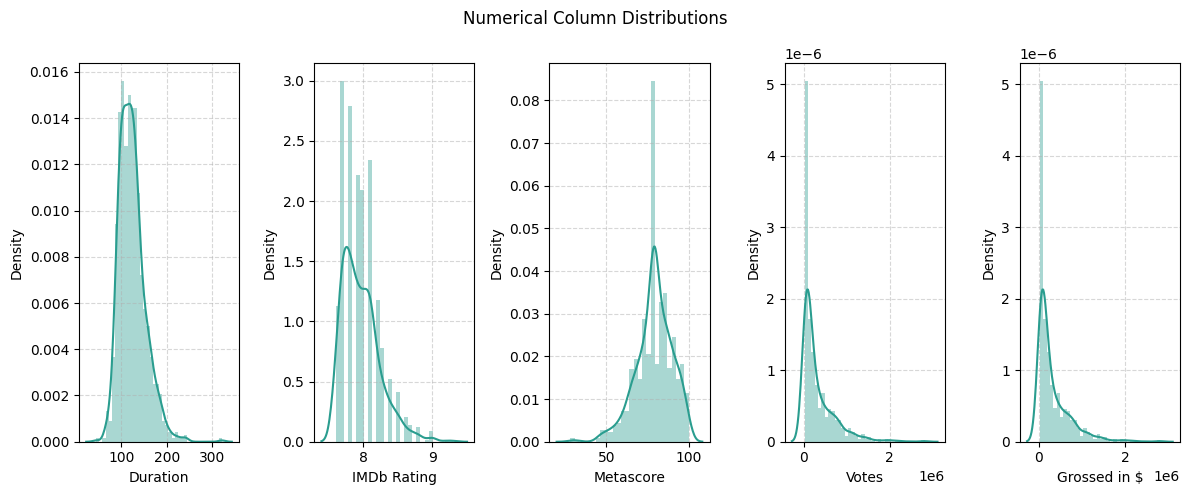

In [ ]:

numerical = df.select_dtypes(exclude='object').columns

plt.figure(figsize=(12,5))
for i in range(len(numerical)):
    plt.subplot(1, len(numerical), i + 1)
    sns.distplot(x=df[numerical[i]], color='#2a9d8f')
    plt.grid(True, linestyle='dashed', alpha=0.5)
    plt.xlabel(numerical[i])
plt.suptitle('Numerical Column Distributions')

plt.tight_layout()
plt.show()

## Boxplot Numerical Columns

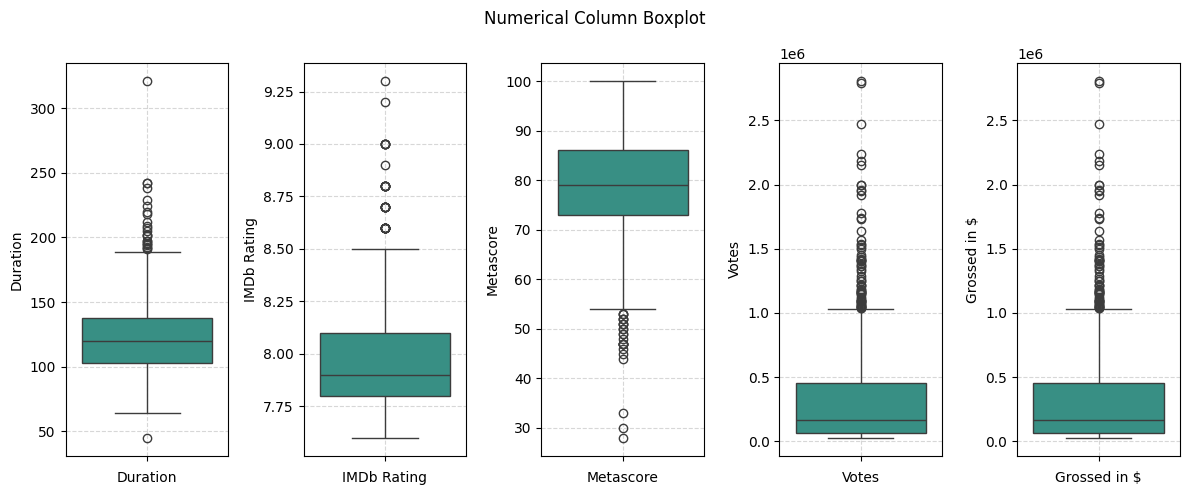

In [ ]:

numerical = df.select_dtypes(exclude='object').columns

plt.figure(figsize=(12,5))
for i in range(len(numerical)):
    plt.subplot(1, len(numerical), i + 1)
    sns.boxplot(y=df[numerical[i]], color='#2a9d8f')
    plt.grid(True, linestyle='dashed', alpha=0.5)
    plt.xlabel(numerical[i])
plt.suptitle('Numerical Column Boxplot')

plt.tight_layout()
plt.show()

# Bivariate Analysis
## Top 10 Movies with the Longest Movie Duration

/tmp/ipykernel_6232/3443037970.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = top10_longest['Duration'], y = top10_longest['Movie Name'],
/tmp/ipykernel_6232/3443037970.py:6: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = top10_longest['Duration'], y = top10_longest['Movie Name'],


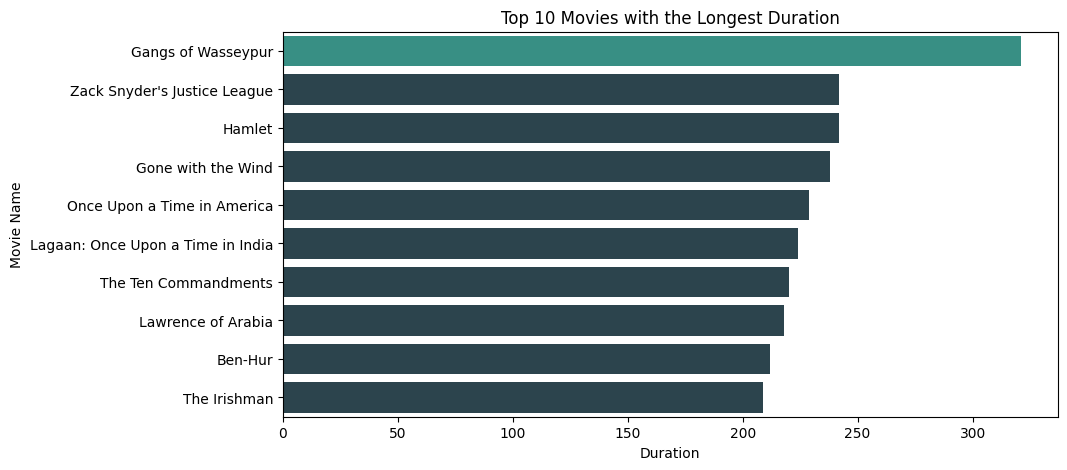

In [ ]:

top10_longest = df[['Movie Name','Duration']].sort_values('Duration', ascending=False).head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(x = top10_longest['Duration'], y = top10_longest['Movie Name'],
                 palette=np.where(top10_longest['Duration'] == np.max(top10_longest['Duration']), '#2a9d8f','#264653'))

plt.title('Top 10 Movies with the Longest Duration')
plt.show()

## Top 10 Movies with Highest IMDb Rating

/tmp/ipykernel_6232/2201751735.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = top10_rating['IMDb Rating'], y = top10_rating['Movie Name'],
/tmp/ipykernel_6232/2201751735.py:5: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = top10_rating['IMDb Rating'], y = top10_rating['Movie Name'],


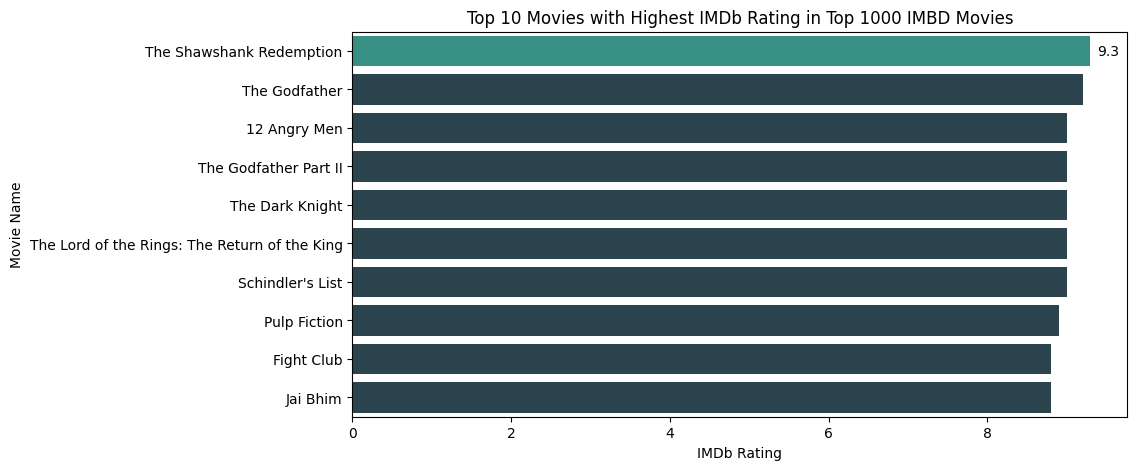

In [ ]:

top10_rating = df[['Movie Name','IMDb Rating']].sort_values(by='IMDb Rating', ascending=False).head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(x = top10_rating['IMDb Rating'], y = top10_rating['Movie Name'],
                 palette=np.where(top10_rating['IMDb Rating'] == np.max(top10_rating['IMDb Rating']), '#2a9d8f','#264653'))
ax.bar_label(ax.containers[0], padding=5)
plt.title('Top 10 Movies with Highest IMDb Rating in Top 1000 IMBD Movies')
plt.show()

## Top 10 Movies with Highest Metascore

/tmp/ipykernel_6232/3318220493.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = top10_metascore['Metascore'], y = top10_metascore['Movie Name'],
/tmp/ipykernel_6232/3318220493.py:5: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = top10_metascore['Metascore'], y = top10_metascore['Movie Name'],


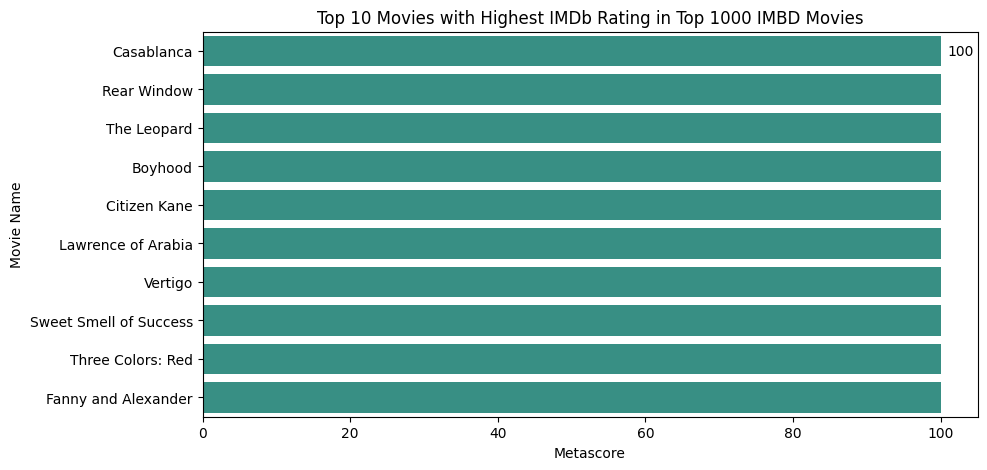

In [ ]:

top10_metascore = df[['Movie Name','Metascore']].sort_values(by='Metascore', ascending=False).head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(x = top10_metascore['Metascore'], y = top10_metascore['Movie Name'],
                 palette=np.where(top10_metascore['Metascore'] == np.max(top10_metascore['Metascore']), '#2a9d8f','#264653'))
ax.bar_label(ax.containers[0], padding=5)
plt.title('Top 10 Movies with Highest IMDb Rating in Top 1000 IMBD Movies')
plt.show()

## Top 10 Movies with Highest Votes

/tmp/ipykernel_6232/4104587007.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = top10_votes['Votes'], y = top10_votes['Movie Name'],
/tmp/ipykernel_6232/4104587007.py:5: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = top10_votes['Votes'], y = top10_votes['Movie Name'],


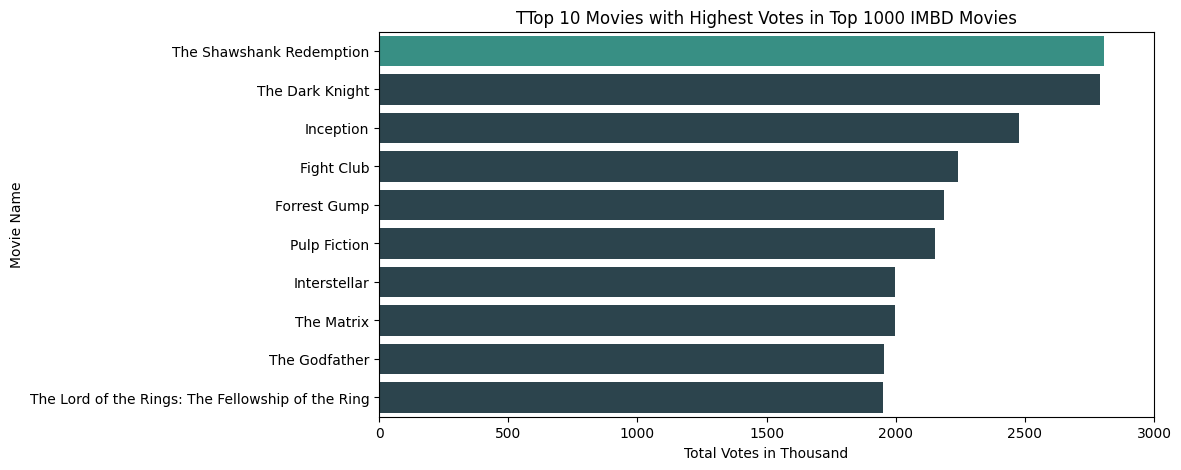

In [ ]:

top10_votes = df[['Movie Name','Votes']].sort_values(by='Votes', ascending=False).head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(x = top10_votes['Votes'], y = top10_votes['Movie Name'],
                 palette=np.where(top10_votes['Votes'] == np.max(top10_votes['Votes']), '#2a9d8f','#264653'))

ax.set_xlabel('Total Votes in Thousand')
labels, location = plt.xticks()
plt.xticks(labels,(labels/1000).astype('int'))
plt.title('TTop 10 Movies with Highest Votes in Top 1000 IMBD Movies')
plt.show()

## Top 10 Movies with Highest Grossed

/tmp/ipykernel_6232/3814070172.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = top10_gross['Grossed in $'], y = top10_gross['Movie Name'],
/tmp/ipykernel_6232/3814070172.py:5: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = top10_gross['Grossed in $'], y = top10_gross['Movie Name'],


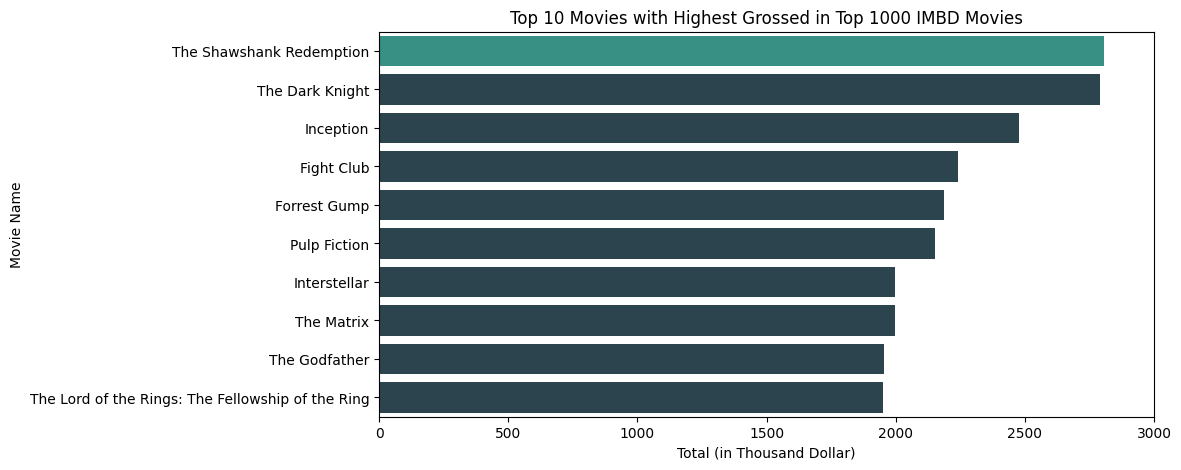

In [ ]:

top10_gross = df[['Movie Name','Grossed in $']].sort_values(by='Grossed in $', ascending=False).head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(x = top10_gross['Grossed in $'], y = top10_gross['Movie Name'],
                 palette=np.where(top10_gross['Grossed in $'] == np.max(top10_gross['Grossed in $']), '#2a9d8f','#264653'))

ax.set_xlabel('Total (in Thousand Dollar)')
labels, location = plt.xticks()
plt.xticks(labels,(labels/1000).astype('int'))
plt.title('Top 10 Movies with Highest Grossed in Top 1000 IMBD Movies')
plt.show()

#Multivariate Analysis
##Pairplot

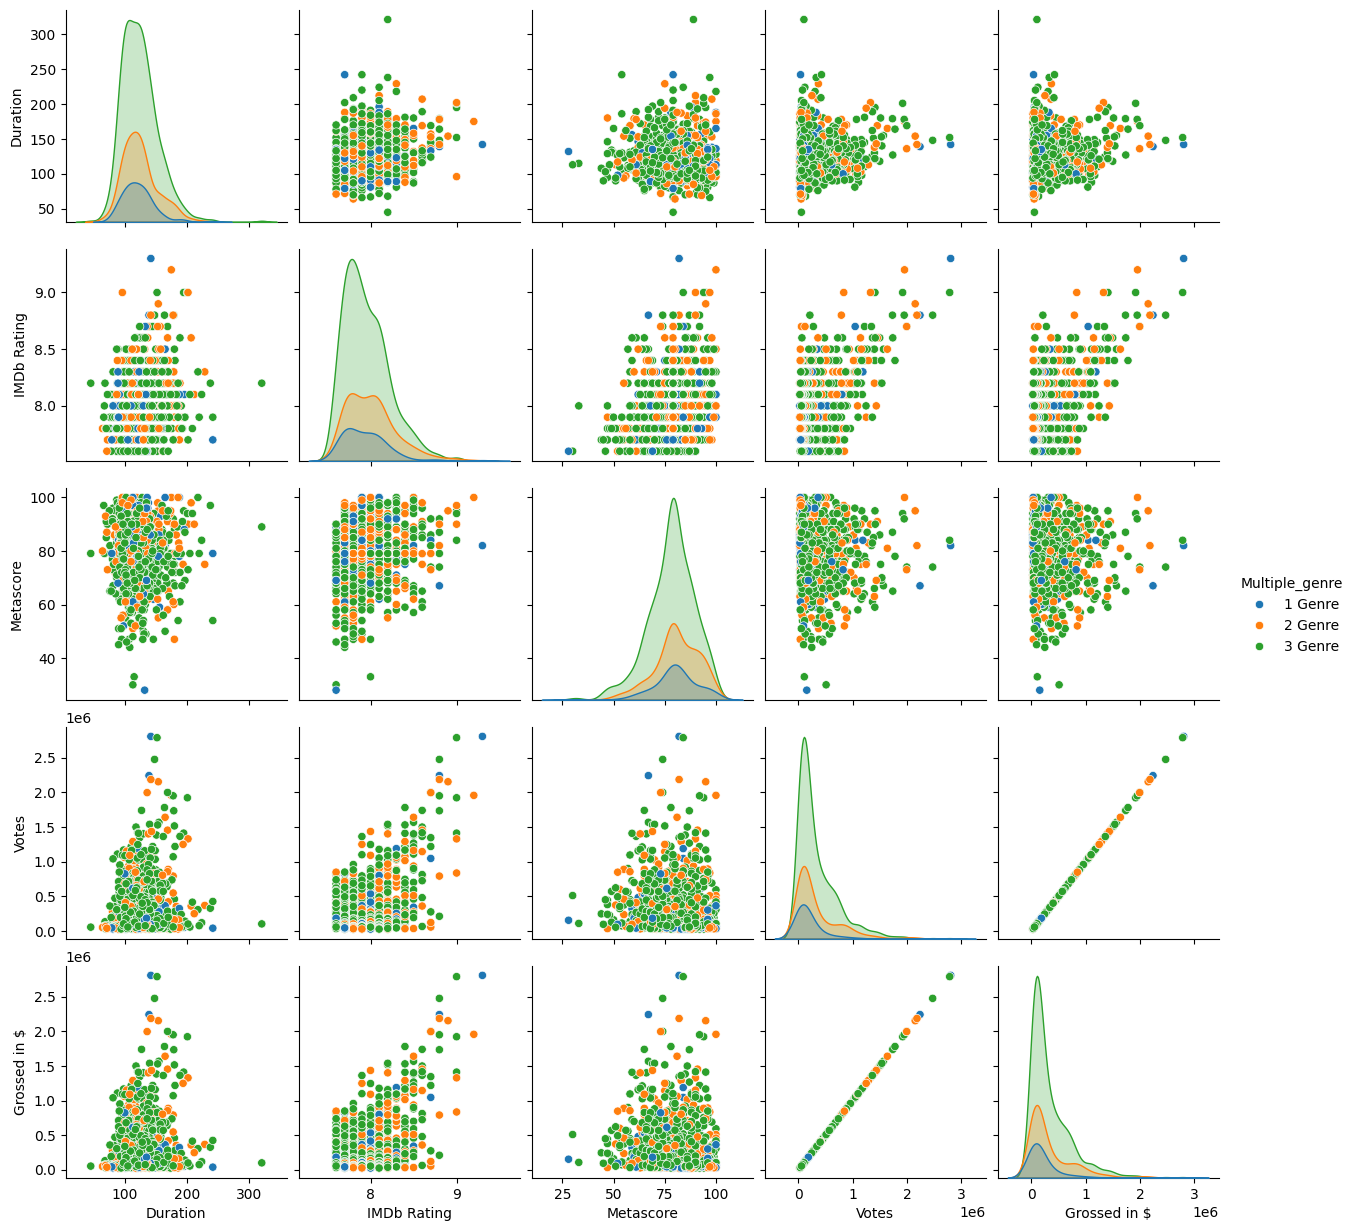

In [40]:
df_scatter = df.copy()
df_scatter['Multiple_genre'] = df['Genre'].apply(lambda x: str(len(x)) + ' Genre' )
sns.pairplot(df_scatter, hue='Multiple_genre')
plt.show()

# Deep Dive Analysis
## Top 10 Directors who earned the highest Grossed Revenue from their movies

/tmp/ipykernel_6232/1213986593.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = top10_gross['sum_grossed'], y = top10_gross['Director'],
/tmp/ipykernel_6232/1213986593.py:10: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = top10_gross['sum_grossed'], y = top10_gross['Director'],


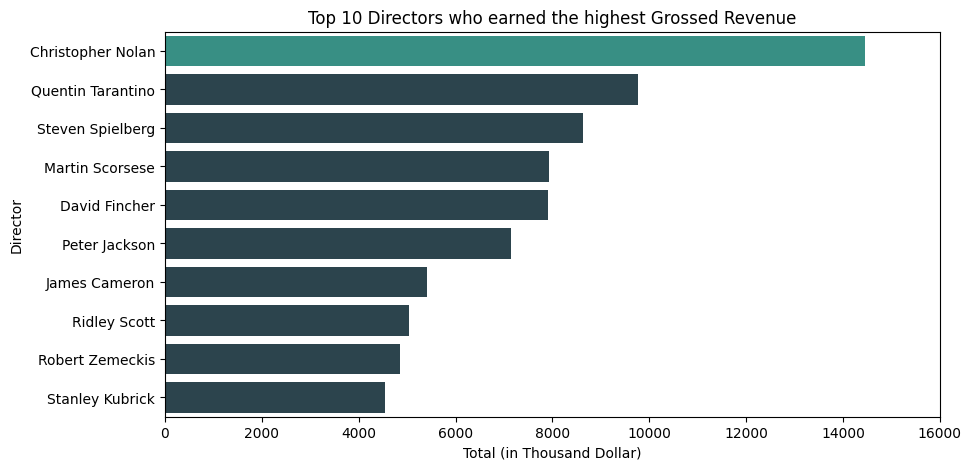

In [ ]:

top10_gross = df[['Director','Grossed in $']].groupby('Director').agg(sum_grossed = ('Grossed in $','sum'))
top10_gross = top10_gross.reset_index().sort_values('sum_grossed',ascending=False).head(10)
top10_gross


plt.figure(figsize=(10,5))
stars = all_stars_counts.head(10)
ax = sns.barplot(x = top10_gross['sum_grossed'], y = top10_gross['Director'],
                 palette=np.where(top10_gross['sum_grossed'] == np.max(top10_gross['sum_grossed']), '#2a9d8f','#264653'))

ax.set_xlabel('Total (in Thousand Dollar)')
labels, location = plt.xticks()
plt.xticks(labels, (labels/1000).astype('int'))
plt.title('Top 10 Directors who earned the highest Grossed Revenue')
plt.show()

## What movie has contributed the most to Director Christopher Nolan Earnings

/tmp/ipykernel_6232/2104159470.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  director = director[condition]
/tmp/ipykernel_6232/2104159470.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = director, x = 'Grossed in $', y='Movie Name',
/tmp/ipykernel_6232/2104159470.py:8: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(data = director, x = 'Grossed in $', y='Movie Name',


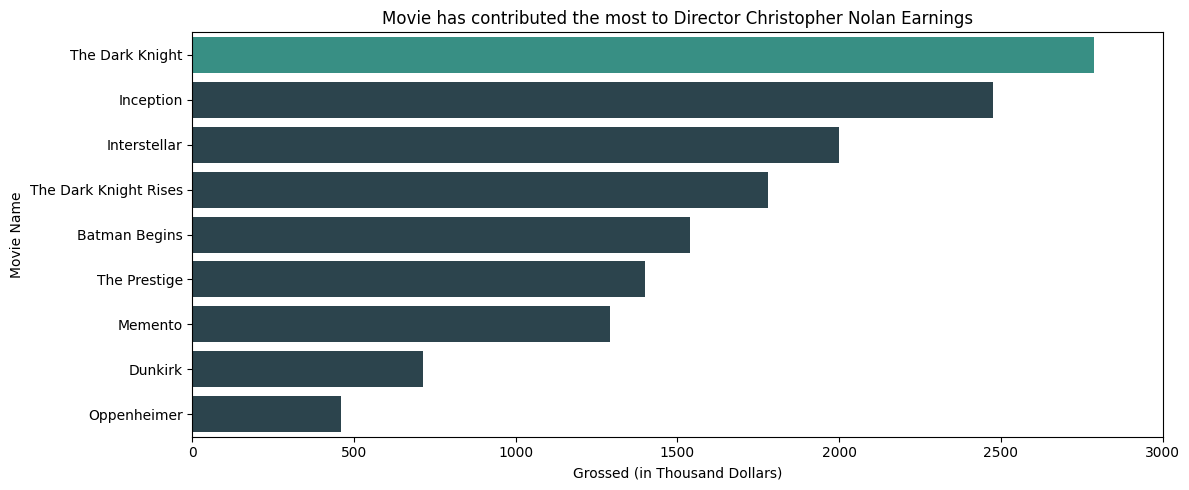

In [ ]:

condition = df['Director'].str.contains('Nolan')
director = df[['Movie Name','Director','Grossed in $']].sort_values('Grossed in $', ascending=False)
director = director[condition]


plt.figure(figsize=(12,5))
sns.barplot(data = director, x = 'Grossed in $', y='Movie Name',
            palette=np.where(director['Grossed in $'] == np.max(director['Grossed in $']), '#2a9d8f','#264653'))
plt.title('Movie has contributed the most to Director Christopher Nolan Earnings')
labels, location = plt.xticks()
plt.xticks(labels, (labels/1000).astype('int'))
plt.xlabel('Grossed (in Thousand Dollars)')
plt.tight_layout()
plt.show()

# Bottom 10 Movie Rating in Top 1000 IMDb Movies

/tmp/ipykernel_6232/2419792778.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bottom10_rating = bottom10_rating[condition]
/tmp/ipykernel_6232/2419792778.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = bottom10_rating, x = 'Movie Name', y='IMDb Rating',
/tmp/ipykernel_6232/2419792778.py:8: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(data = bottom10_rating, x = 'Movie Name', y='IMDb Rating',


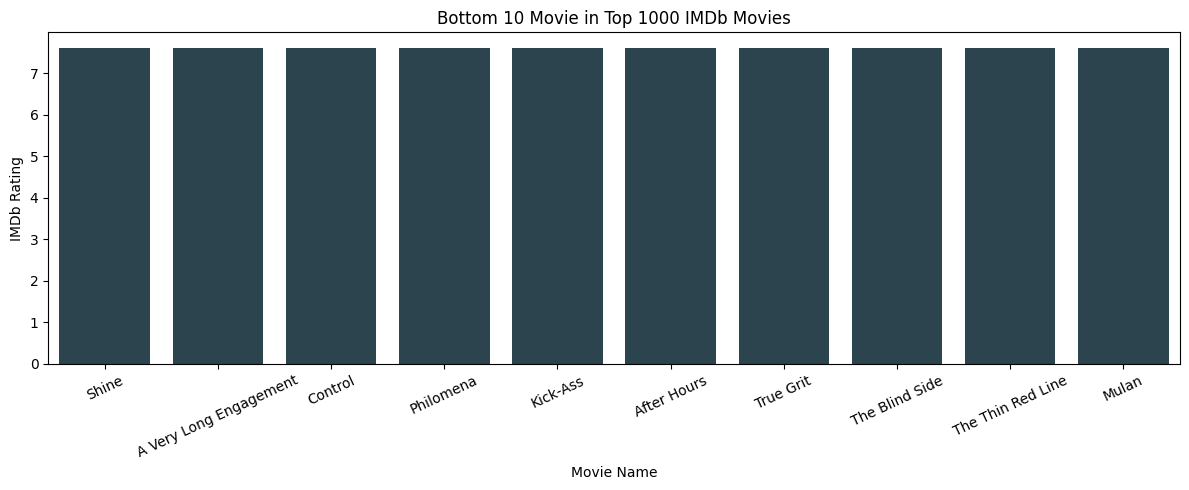

In [ ]:

condition = df['IMDb Rating'] < np.mean(df['IMDb Rating'])
bottom10_rating = df[['Movie Name', 'IMDb Rating']].sort_values('IMDb Rating', ascending= True).head(10)
bottom10_rating = bottom10_rating[condition]
bottom10_rating

plt.figure(figsize=(12,5))
sns.barplot(data = bottom10_rating, x = 'Movie Name', y='IMDb Rating',
            palette=np.where(bottom10_rating['IMDb Rating'] < np.mean(bottom10_rating['IMDb Rating']), '#2a9d8f','#264653'))
plt.title('Bottom 10 Movie in Top 1000 IMDb Movies')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Bottom 10 Directors who earned the lowest Grossed Revenue from their movies

/tmp/ipykernel_6232/225639873.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = bottom10_gross['sum_grossed'], y = bottom10_gross['Director'],
/tmp/ipykernel_6232/225639873.py:9: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x = bottom10_gross['sum_grossed'], y = bottom10_gross['Director'],


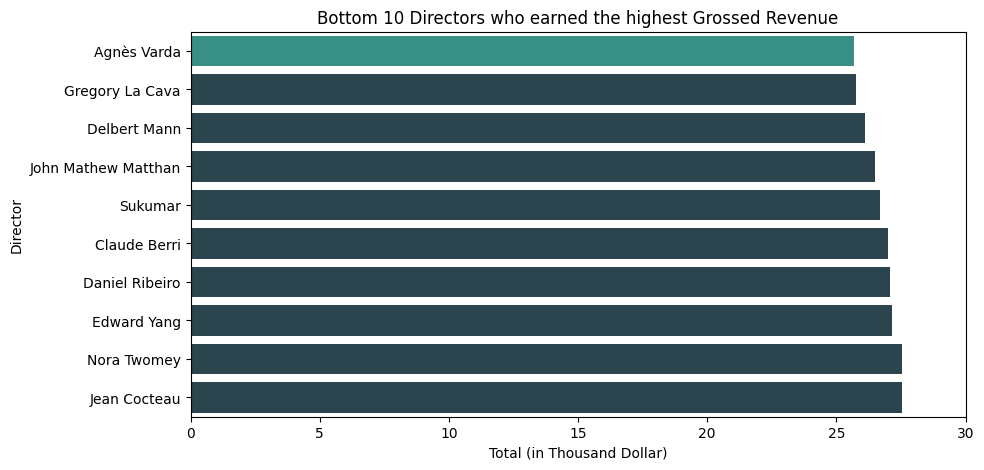

In [ ]:

bottom10_gross = df[['Director','Grossed in $']].groupby('Director').agg(sum_grossed = ('Grossed in $','sum'))
bottom10_gross = bottom10_gross.reset_index().sort_values('sum_grossed',ascending=True).head(10)
bottom10_gross


plt.figure(figsize=(10,5))
stars = all_stars_counts.head(10)
ax = sns.barplot(x = bottom10_gross['sum_grossed'], y = bottom10_gross['Director'],
                 palette=np.where(bottom10_gross['sum_grossed'] == np.min(bottom10_gross['sum_grossed']), '#2a9d8f','#264653'))

ax.set_xlabel('Total (in Thousand Dollar)')
labels, location = plt.xticks()
plt.xticks(labels, (labels/1000).astype('int'))
plt.title('Bottom 10 Directors who earned the highest Grossed Revenue')
plt.show()